Step 1: Install necessary dependencies

In [ ]:
pip install numpy pandas matplotlib scikit-learn

Step 2: Add necessary imports

Import core libraries for data handling, modeling, scaling, cross-validation, and evaluation. These tools support the full Ridge regression workflow.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Step 3: Load the Dataset and Define the Target Variable

Load the dataset and separate the target variable (`SP500`) from the predictor variables. `X` contains inputs, and `y` is what the model will predict.

Step 4: Prepare the Date Variable for Regression

Convert the `Date` column into numeric features (`Year` and `Month`) so the model can use time information. Remove the original date and store feature names for later interpretation.

In [ ]:
#grab the data from csv, and set Y to output, X to features matrix
df = pd.read_csv('../data/combined_monthly.csv')
# df = pd.read_csv('../data/combined_monthly.csv') does not perform well
y = df['SP500']
X = df.drop(columns=['SP500'])

# Convert date into numeric calendar features for modeling
X['Date'] = pd.to_datetime(X['Date'])
X['Year'] = X['Date'].dt.year
X['Month'] = X['Date'].dt.month
X = X.drop(columns=['Date'])

feature_names = X.columns.tolist()
display(feature_names)

['Crude_Oil',
 'US_10Y_Yield',
 'Copper',
 'Steel_PPI',
 'CPI',
 'Unemployment_Rate',
 'Year',
 'Month']

Step 5: Preview X and Y

Preview the predictor variables to confirm the data is loaded and formatted correctly. Check the target variable (`SP500`) to ensure it is correctly selected and aligned with the predictors.

In [26]:
display(X)
display(y)

,Crude_Oil,US_10Y_Yield,Copper,Steel_PPI,CPI,Unemployment_Rate,Year,Month
0,92.190002,3.378,4.4510,220.400,221.187,9.1,2011,1
1,96.970001,3.414,4.4780,239.800,221.898,9.0,2011,2
2,106.720001,3.454,4.3000,248.100,223.046,9.0,2011,3
3,113.930000,3.296,4.1655,257.300,224.093,9.1,2011,4
4,95.419998,3.158,4.2720,250.300,224.806,9.1,2011,6
...,...,...,...,...,...,...,...,...
133,75.849998,3.967,3.9025,433.171,309.698,3.7,2024,1
134,78.260002,4.252,3.8345,454.090,310.967,3.9,2024,2
135,83.169998,4.206,4.0035,396.888,312.345,3.9,2024,3
136,81.930000,4.686,4.5645,385.577,313.023,3.9,2024,4


0      1286.119995
1      1327.219971
2      1325.829956
3      1363.609985
4      1320.640015
          ...     
133    4845.649902
134    5096.270020
135    5254.350098
136    5035.689941
137    5277.509766
Name: SP500, Length: 138, dtype: float64

Step 6: Train-Test Split and Scaling

Split the data into 80% training and 20% testing using time order. Standardize features so Ridge regression applies regularization fairly across variables.

In [27]:
# 80% of data for training 
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Step 7: Cross-Validation Setup

Use time-series cross-validation to preserve time order. Define a range of alpha values to test different levels of regularization. Use GridSearchCV to test multiple alpha values with cross-validation and select the Ridge model with the lowest validation error.

In [28]:
# Tune Ridge with time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)
# Create 60 values between 0.0001 to 1000
param_grid = {'alpha': np.logspace(-4, 3, 60)}

ridge_search = GridSearchCV(
    estimator=Ridge(random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=tscv
)

ridge_search.fit(X_train, y_train)

ridge = ridge_search.best_estimator_
print(f"Best alpha: {ridge_search.best_params_['alpha']:.6f}")
print(f"Best CV RMSE: {np.sqrt(-ridge_search.best_score_):.4f}")

Best alpha: 0.007912
Best CV RMSE: 438.3930


Step 8: Model Evaluation

Make predictions on the test set and evaluate performance using MSE, RMSE, MAE, and R².

In [29]:
# Ridge predictions and evaluation metrics
y_pred_ridge = ridge.predict(X_test)

ridge_metrics = {
    'MSE': mean_squared_error(y_test, y_pred_ridge),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
    'MAE': mean_absolute_error(y_test, y_pred_ridge),
    'R2': r2_score(y_test, y_pred_ridge)
}

print(pd.Series(ridge_metrics).round(4))

MSE     291448.4913
RMSE       539.8597
MAE        417.6551
R2          -0.4953
dtype: float64


Step 9: Diagnostic Plots

Plot actual vs predicted values and residuals to visually assess model performance and error patterns.

Top 10 absolute coefficients:
Year                 982.274203
CPI                 -201.867477
Steel_PPI            135.512994
Copper               122.248626
Month                 85.417477
Crude_Oil             65.325907
US_10Y_Yield         -33.623167
Unemployment_Rate    -19.409458
dtype: float64


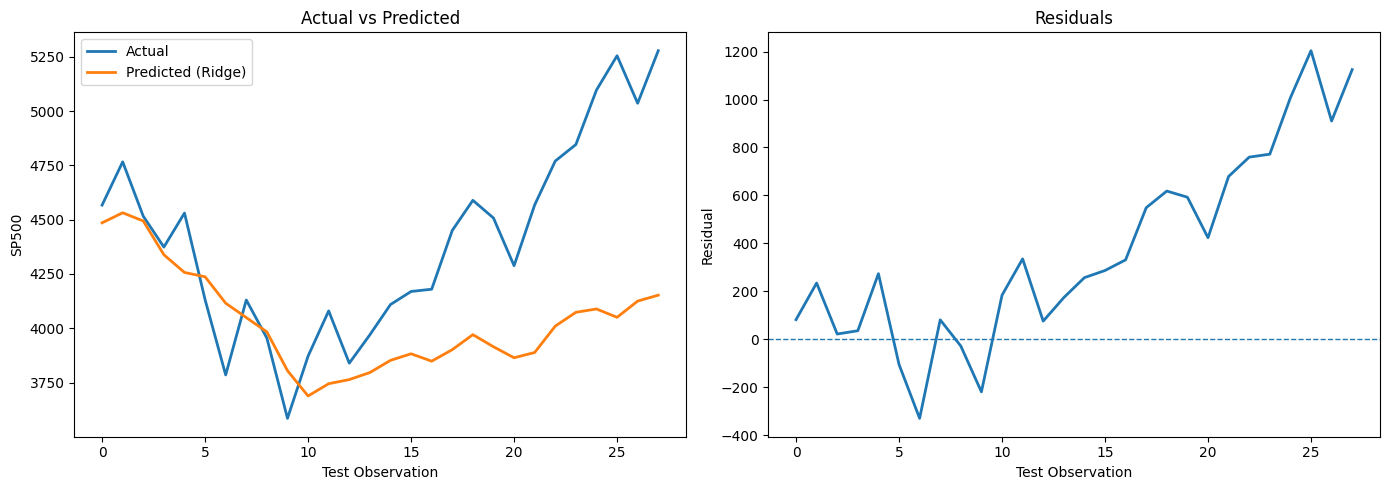

In [30]:
# Coefficient analysis
coefficients = pd.Series(ridge.coef_, index=feature_names).sort_values(key=np.abs, ascending=False)
print('Top 10 absolute coefficients:')
print(coefficients.head(10))

# Diagnostic plots: actual vs predicted and residuals
residuals = y_test - y_pred_ridge

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(y_test.values, label='Actual', linewidth=2)
axes[0].plot(y_pred_ridge, label='Predicted (Ridge)', linewidth=2)
axes[0].set_title('Actual vs Predicted')
axes[0].set_xlabel('Test Observation')
axes[0].set_ylabel('SP500')
axes[0].legend()

axes[1].plot(residuals.values, linewidth=2)
axes[1].axhline(0, linestyle='--', linewidth=1)
axes[1].set_title('Residuals')
axes[1].set_xlabel('Test Observation')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()